وقتی داده ها فیلتر شدند این برنامه نمودار تولید بر اساس دما را برای تمام واحدهای تولیدی رسم کرده و داده های مربوط به آخرین سری تولید و داده های انتخاب شده توسط فیلتر پنجم را نیز مشخص میکند. 

In [2]:
import os
import sys

import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

In [3]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")
df_c = pd.read_csv(csv_read_path, encoding='utf-8')

In [109]:
csv_read_path = os.path.join(project_root, "data", "interim", "factors.csv")
df_factors = pd.read_csv(csv_read_path)

coefs = {}
grouped = df_factors.groupby(['PowerPlantCode', 'PowerPlantName', "UnitCode"])

for (pp_code, pp_name, unit_code), g in grouped:
    uniques = g[["a1IndexGas", "b1IndexGas"]].drop_duplicates()
    coefs[(pp_name, unit_code)] = []
    for row in uniques.itertuples(index=False):
        coefs[(pp_name, unit_code)].append((row.a1IndexGas, row.b1IndexGas))

In [19]:
def get_Xy(df, name, code):
    ds = Data_selector(Data_selector(df).select_peaks(goodness=5))
    df_plot = ds.filter_name_code(name, code)
    try:
        features = ["generation", f"{temp_feature}"]
        df_modified = df_plot[features].copy(deep=True)
    
        sens_temps = df_modified[temp_feature].values
        gens = df_modified['generation'].values
    
        X, y = find_points_on_envelope(gens, sens_temps, bin_length=100, p=0.95)
        print(name, code, int(len(df_plot) / (365 * 24) * 10) / 10)
        return X.flatten(), y
    except:
        print(name, code, "None")
        return None,None


In [113]:
power_plants = df_c[['name', 'code']].drop_duplicates()
Xy_by_name_code = {}
for row in power_plants.itertuples():
    name, code = row.name, row.code
    X,y = get_Xy(df_c, name, code)
    Xy_by_name_code[(name, code)] = X,y

جنوب اصفهان - چهلستون G11 3.1
جنوب اصفهان - چهلستون G12 1.3
جنوب اصفهان - چهلستون G13 1.1
جنوب اصفهان - چهلستون G14 1.0
جنوب اصفهان - چهلستون G15 1.0
جنوب اصفهان - چهلستون G16 1.2
حافظ G11 3.3
حافظ G12 1.2
حافظ G13 1.1
حافظ G14 1.2
حافظ G15 1.2
حافظ G16 1.2
سبلان G11 2.6
سبلان G12 1.1
سبلان G13 0.7
سبلان G14 0.2
سبلان G15 0.9
سبلان G16 0.9
سیکل ترکیبی ارومیه G11 2.1
سیکل ترکیبی ارومیه G12 1.3
سیکل ترکیبی ارومیه G13 1.1
سیکل ترکیبی ارومیه G14 1.2
سیکل ترکیبی ارومیه G15 1.0
سیکل ترکیبی ارومیه G16 1.0
سیکل ترکیبی شیروان G11 3.0
سیکل ترکیبی شیروان G12 1.1
سیکل ترکیبی شیروان G13 1.2
سیکل ترکیبی شیروان G14 1.2
سیکل ترکیبی شیروان G15 0.9
سیکل ترکیبی شیروان G16 0.9
سیکل ترکیبی یزد G11 1.7
سیکل ترکیبی یزد G12 0.8
سیکل ترکیبی یزد G13 0.0
سیکل ترکیبی یزد G14 0.2
سیکل ترکیبی یزد G15 0.3
سیکل ترکیبی یزد G16 1.2
شهدای پاکدشت - دماوند G11 3.2
شهدای پاکدشت - دماوند G12 1.2
شهدای پاکدشت - دماوند G13 0.5
شهدای پاکدشت - دماوند G14 1.1
شهدای پاکدشت - دماوند G15 1.1
شهدای پاکدشت - دماوند G16 1.2
شهدای پاکد

In [114]:
def draw_plot(X, y, t_c, fig, name, code):
    
    X = X.flatten()
    y_i = y[X > t_c]
    X_i = X[X > t_c]
    
    fig.add_trace(
        go.Scatter(
            x=X_i,
            y=y_i,
            #mode='markers',
            mode="lines",
            name=f"set {name}-{code}"
        )
    )
    
    for i in range(len(coefs[(name, code)])):
        a, b = coefs[(name, code)][i]
        x_line = np.linspace(-10, 50, 100)
        y_line = a * x_line + b
        
        fig.add_trace(go.Scatter(
            x=x_line,
            y=y_line,
            mode="lines",
            name=f"y = {a}x + {b}",
            line=dict(dash="dash", width=2)
        ))
    

In [115]:
from src.models import utils
def err_line(X,y,model,th):
    model.fit(X.reshape(-1,1),y)
    y_i_pred = model.predict(X.reshape(-1,1))
    err = utils.compute_relative_rmse(y_i_pred,y)
    return err

72 34


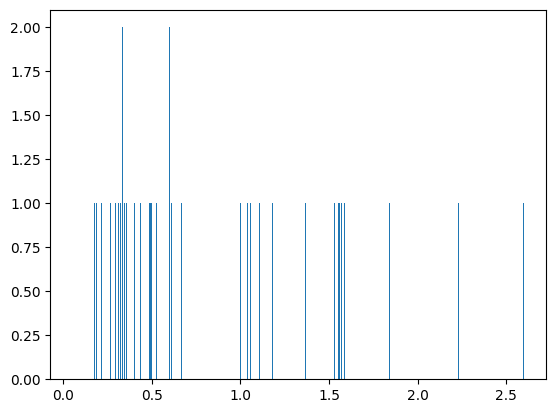

In [116]:
import plotly.graph_objects as go

fig = go.Figure()
t_c = 0
th = 2
t = 0
errors = []
kk = 7
h = np.array([1]*(2*kk+1))/(2*kk+1)
for row in power_plants.itertuples():
    name, code = row.name, row.code
    X,y = Xy_by_name_code[(name, code)]
    if len(y) < len(h) : continue
    y = np.convolve(y, h, mode="valid")
    X = np.array(X)[kk:-kk]
    err = err_line(X,y,model=LinearRegression(),th=th)
    if 0.5 > err:   
        draw_plot(X, y, t_c, fig, name, code)
        t +=1
    errors.append(err)
print(len(power_plants),t)

fig.update_layout(
    title="Multiple XY Sets",
    xaxis_title="Time",
    yaxis_title="Generation"
)
fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5/ALL.html")
_ = plt.hist(errors,bins = 1000)

In [92]:
import plotly.graph_objects as go
from collections import defaultdict

# یک دیکشنری برای جمع کردن داده‌های هر name
plots = defaultdict(list)

# جدا کردن داده‌های هر name
for row in power_plants.itertuples():
    name, code = row.name, row.code
    X, y = Xy_by_name_code[(name, code)]
    plots[name].append((code, X, y))

# برای هر name یک نمودار جدا بساز
for name, items in plots.items():
    fig = go.Figure()

    for code, X, y in items:
        fig.add_trace(
            go.Scatter(
                x=X,
                y=y,
                mode="markers",
                name=f"{name}-{code}"
            )
        )

    fig.update_layout(
        title=f"{name} - Units",
        xaxis_title="Time",
        yaxis_title="Generation"
    )

    fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter5/{name}.html"
        )
